# Point-based sampling: Olofsson area estimates vs. pixel-level F1

Tests whether a single Olofsson-style point sample, drawn from the "larger landscape"
(all validation grid-cell stacks pooled), can distinguish maps of varying quality.

**Two comparisons per sensor:**
1. Olofsson area estimate ± 95% CI vs. true disturbed proportion
2. Sample-based F1 (Olofsson-corrected confusion proportions) vs. pixel-level F1 (full map)

Config: `interpreter/experiments/configs/map_comparison_point_vs_all.json`

In [1]:
import sys, os, json

def find_project_root(marker='.git', start=None):
    """Walk upward from `start` (default: cwd) until `marker` is found.

    Jupyter kernel CWD for this notebook varies by machine/VS Code settings
    (sometimes the repo root, sometimes interpreter/notebooks/) — searching
    for a marker that only exists at the true root makes PROJ_ROOT immune
    to that.
    """
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(f"Could not find project root (marker: {marker!r}) above {start or os.getcwd()}")
        path = parent

PROJ_ROOT = find_project_root()
sys.path.insert(0, os.path.join(PROJ_ROOT, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from landscape_stack_collection import LandscapeStackCollection
from map_comparison import (
    perfect_reference_mask,
    pixel_level_metrics_for_collection,
)

In [2]:
with open(os.path.join(PROJ_ROOT, 'interpreter/experiments/configs/map_comparison_point_vs_all.json')) as f:
    cfg = json.load(f)

stack_cfg     = cfg['landscape_stack_config']
train_exp_cfg = dict(cfg['training_experiment_config'])
val_exp_cfg   = dict(cfg['validation_experiment_config'])
train_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, train_exp_cfg['patch_dir'])
val_exp_cfg['patch_dir']   = os.path.join(PROJ_ROOT, val_exp_cfg['patch_dir'])

bc_cfg = cfg['binary_classifier_config']
ps_cfg = cfg['point_sample_config']

SENSOR_NAMES        = [s['name'] for s in stack_cfg['sensors']]
N_SAMPLES_PER_CLASS = {int(k): v for k, v in ps_cfg['n_samples_per_class'].items()}
SAMPLE_SEED         = ps_cfg['sampling_seed']   # None → random each run

print('Sensors:', SENSOR_NAMES)
print('Samples per class:', N_SAMPLES_PER_CLASS)

Sensors: ['Sensor_Clean', 'Sensor_X', 'Sensor_Y', 'Sensor_Z']
Samples per class: {0: 50, 1: 50}


## 1. Build collections and classifiers

In [3]:
train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=train_exp_cfg,
)

train_collection.buildBinaryClassifier(
    sensor_names=bc_cfg['sensor_names'],
    n_strata=bc_cfg['n_strata'],
    samples_per_stratum=bc_cfg['samples_per_stratum'],
    sampling_seed=bc_cfg['sampling_seed'],
    fp_to_fn_ratio=bc_cfg['fp_to_fn_ratio'],
)
train_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


In [4]:
used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=val_exp_cfg,
    exclude_tif_paths=used_tifs,
)

assert set(used_tifs).isdisjoint(
    {s.base_landscape.tif_path for s in val_collection.stacks}
), 'validation set overlaps training set'

val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

print(f'{len(val_collection.stacks)} validation stacks')

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


20 validation stacks


## 1b. Visual inspection — sensor maps for a chosen landscape

Change `LANDSCAPE_IDX` to any value from `0` to `len(val_collection.stacks) - 1`.

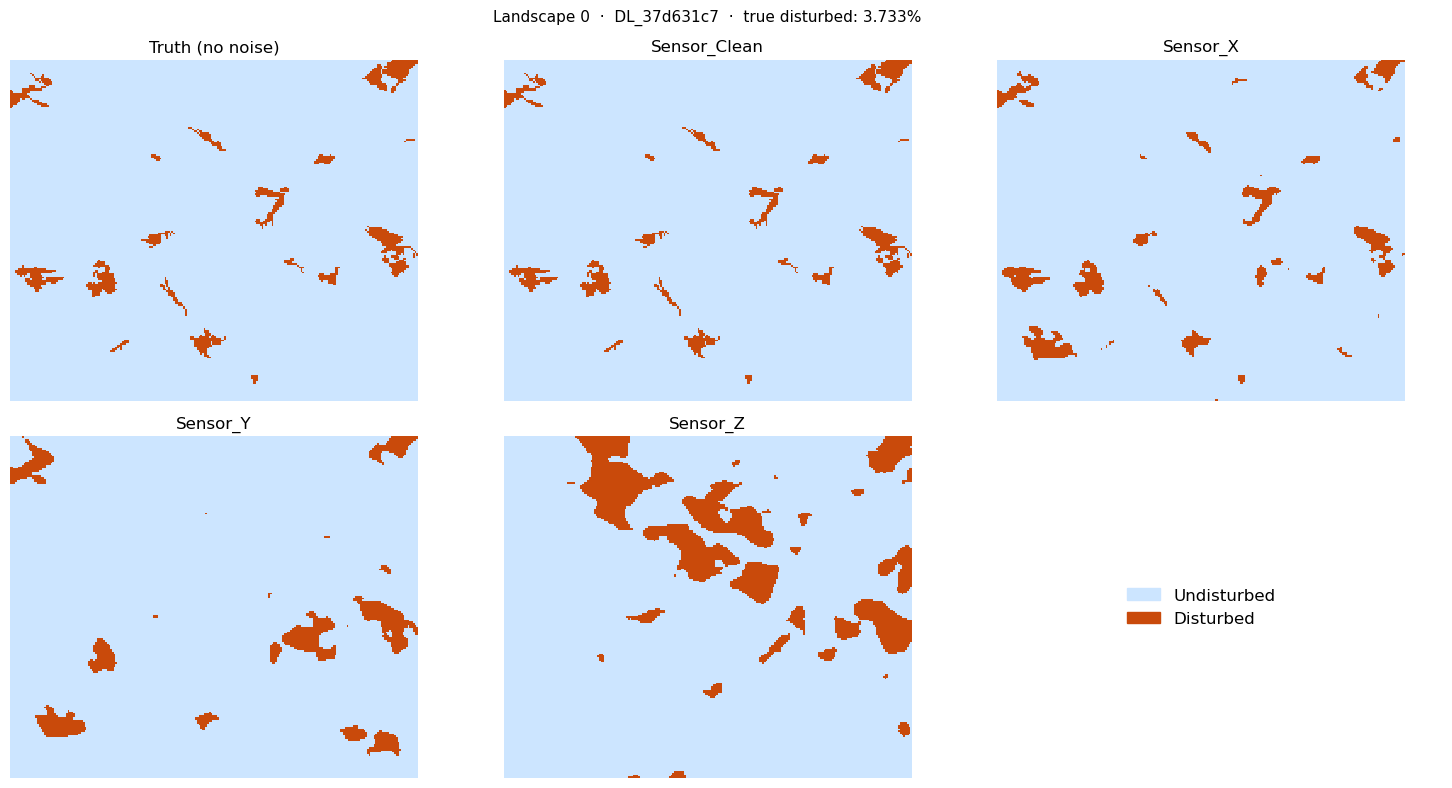

In [5]:
from matplotlib.colors import ListedColormap

# ── Change this to inspect a different validation landscape ───────────────────
LANDSCAPE_IDX = 0   # 0  to  len(val_collection.stacks) - 1
# ─────────────────────────────────────────────────────────────────────────────

CMAP_BINARY = ListedColormap(['#cce5ff', '#c94a0b'])  # undisturbed=pale blue, disturbed=brick red

stack = val_collection.stacks[LANDSCAPE_IDX]
panels = [('Truth (no noise)', stack.base_landscape.disturbed.astype(int))] + [
    (s, stack.binary_class_by_sensor[s]) for s in SENSOR_NAMES
]

n_panels = len(panels)
n_cols   = 3
n_rows   = (n_panels + 1 + n_cols - 1) // n_cols  # +1 slot for legend

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_list = list(axes.flat)

for i, (title, arr) in enumerate(panels):
    axes_list[i].imshow(arr, cmap=CMAP_BINARY, vmin=0, vmax=1, interpolation='nearest')
    axes_list[i].set_title(title)
    axes_list[i].axis('off')

# Legend goes in the next slot after the panels
ax_leg = axes_list[n_panels]
ax_leg.axis('off')
ax_leg.legend(
    handles=[
        mpatches.Patch(color='#cce5ff', label='Undisturbed'),
        mpatches.Patch(color='#c94a0b', label='Disturbed'),
    ],
    loc='center', fontsize=12, frameon=False,
)

for ax in axes_list[n_panels + 1:]:
    ax.axis('off')

fig.suptitle(
    f'Landscape {LANDSCAPE_IDX}  ·  {stack.stack_id}  ·  '
    f'true disturbed: {stack.base_landscape.disturbed.mean():.3%}',
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 2. Pixel-level F1 — ground truth map quality

Computed from the full binary map vs. the perfect-interpreter reference for every pixel
across all validation stacks. This is what the maps *truly* look like.

In [6]:
pixel_df = pixel_level_metrics_for_collection(
    val_collection, sensor_names=SENSOR_NAMES
)
pixel_summary = pixel_df.groupby('sensor_name')[['agreement', 'precision', 'recall', 'f1', 'iou']].mean()
pixel_f1 = pixel_summary['f1']   # Series indexed by sensor_name
pixel_summary

,agreement,precision,recall,f1,iou
sensor_name,,,,,
Sensor_Clean,0.998576,0.934194,0.991164,0.959868,0.926382
Sensor_X,0.986661,0.647713,0.859083,0.732596,0.583054
Sensor_Y,0.970916,0.379617,0.538616,0.432749,0.279217
Sensor_Z,0.928341,0.122486,0.367017,0.177183,0.099034


## 3. Point-based Olofsson sample — one draw from the larger landscape

Samples `n_per_class` pixels per map class from the pooled validation collection
(all grid-cell stacks together = the "larger landscape"). For each sensor:

- **Olofsson area estimate**: `P_hat[1] ± SE[1]` (95% CI via Olofsson formula)
- **Corrected F1**: derived from the Olofsson-weighted confusion proportions
  `W[i] × p_ij[i,j]`, which correctly accounts for the stratified sample design

In [7]:
def corrected_f1_from_olofsson(olf: dict) -> float:
    """F1 for class 1 from Olofsson-weighted confusion proportions."""
    W    = olf['W']
    p_ij = olf['p_ij']
    TP   = W[1] * p_ij[1, 1]
    FP   = W[1] * p_ij[1, 0]
    FN   = W[0] * p_ij[0, 1]
    denom = 2 * TP + FP + FN
    return float(2 * TP / denom) if denom > 0 else float('nan')


results = {}
for sensor_name in SENSOR_NAMES:
    samples = val_collection.binary_stratified_sample(
        sensor_name=sensor_name,
        n_samples_per_class=N_SAMPLES_PER_CLASS,
        sampling_seed=SAMPLE_SEED,
    )
    olf = val_collection.olofsson_area_estimates(samples, sensor_name=sensor_name)

    results[sensor_name] = {
        'p_hat':      float(olf['P_hat'][1]),
        'se':         float(olf['SE'][1]),
        'ci_lo':      float(olf['CI']['lower'][1]),
        'ci_hi':      float(olf['CI']['upper'][1]),
        'true_prop':  float(olf['true_disturbed_prop']),
        'f1_sample':  corrected_f1_from_olofsson(olf),
        'n_class0':   int(olf['n_i_samples'][0]),
        'n_class1':   int(olf['n_i_samples'][1]),
    }

results_df = pd.DataFrame(results).T
results_df[['p_hat', 'se', 'ci_lo', 'ci_hi', 'true_prop', 'f1_sample', 'n_class0', 'n_class1']]

,p_hat,se,ci_lo,ci_hi,true_prop,f1_sample,n_class0,n_class1
Sensor_Clean,0.021577,0.000909,0.019795,0.023358,0.022476,0.958333,50.0,50.0
Sensor_X,0.018970,0.002033,0.014986,0.022954,0.022476,0.780488,50.0,50.0
Sensor_Y,0.013253,0.002225,0.008892,0.017614,0.022476,0.591549,50.0,50.0
Sensor_Z,0.007061,0.003026,0.001130,0.012992,0.022476,0.181818,50.0,50.0


## 4. Visualization

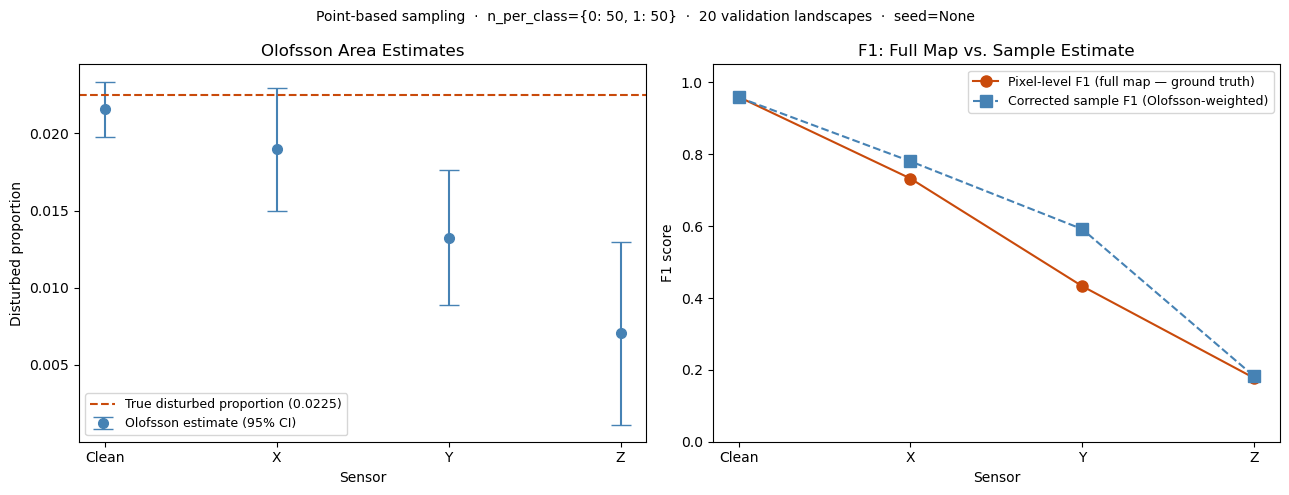

In [8]:
labels   = [s.replace('Sensor_', '') for s in SENSOR_NAMES]
x        = np.arange(len(SENSOR_NAMES))
true_prop = results[SENSOR_NAMES[0]]['true_prop']  # same for all sensors

p_hats   = [results[s]['p_hat']    for s in SENSOR_NAMES]
ci_lo    = [results[s]['ci_lo']    for s in SENSOR_NAMES]
ci_hi    = [results[s]['ci_hi']    for s in SENSOR_NAMES]
f1_samp  = [results[s]['f1_sample'] for s in SENSOR_NAMES]
f1_pix   = [float(pixel_f1[s])     for s in SENSOR_NAMES]

fig, (ax_area, ax_f1) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: Olofsson area estimates ──────────────────────────────────────
err_lo = [p - lo for p, lo in zip(p_hats, ci_lo)]
err_hi = [hi - p for hi, p in zip(ci_hi, p_hats)]

ax_area.errorbar(
    x, p_hats, yerr=[err_lo, err_hi],
    fmt='o', capsize=7, ms=7, color='steelblue',
    label='Olofsson estimate (95% CI)',
)
ax_area.axhline(
    true_prop, color='#c94a0b', linestyle='--', lw=1.5,
    label=f'True disturbed proportion ({true_prop:.4f})',
)
ax_area.set_xticks(x)
ax_area.set_xticklabels(labels)
ax_area.set_xlabel('Sensor')
ax_area.set_ylabel('Disturbed proportion')
ax_area.set_title('Olofsson Area Estimates')
ax_area.legend(fontsize=9)

# ── Right panel: F1 comparison ────────────────────────────────────────────────
ax_f1.plot(
    x, f1_pix, 'o-', color='#c94a0b', ms=8, lw=1.5,
    label='Pixel-level F1 (full map — ground truth)',
)
ax_f1.plot(
    x, f1_samp, 's--', color='steelblue', ms=8, lw=1.5,
    label='Corrected sample F1 (Olofsson-weighted)',
)
ax_f1.set_xticks(x)
ax_f1.set_xticklabels(labels)
ax_f1.set_xlabel('Sensor')
ax_f1.set_ylabel('F1 score')
ax_f1.set_ylim(0, 1.05)
ax_f1.set_title('F1: Full Map vs. Sample Estimate')
ax_f1.legend(fontsize=9)

n_stacks = len(val_collection.stacks)
fig.suptitle(
    f'Point-based sampling  ·  '
    f'n_per_class={N_SAMPLES_PER_CLASS}  ·  '
    f'{n_stacks} validation landscapes  ·  '
    f'seed={SAMPLE_SEED}',
    fontsize=10,
)
fig.tight_layout()
plt.show()